#### Prdict the weight base on a given height

In [8]:
# %pip install pandas
# %pip install numpy
import pandas as pd # type: ignore
import numpy as np # type: ignore
from sklearn.linear_model import LinearRegression # type: ignore
from sklearn.model_selection import train_test_split # type: ignore

heihgt = np.array([147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183])
weight = np.array([49, 50, 51, 54, 58, 59, 60, 62, 63, 64, 66, 67, 68])

heihgt = heihgt.reshape(-1, 1)
X_train , X_test , y_train , y_test = train_test_split(heihgt, weight, test_size=0.2, random_state=0) # 80% training and 20% test

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_predicted = model.predict(X_test)
y_predicted

array([60.16718179, 66.88367519, 57.36864288])

In [10]:
new_height = 175
new_weight = model.predict([[new_height]]) # want to mainrtain x and y axis , using to array
new_weight # 64.5

array([64.08513627])

# Logistic Regression

#### we can get yes or no answer 
#### this is statistical method used for binary classification
#### Widly used in varius fealds
#### Provide probabilities
#### have sigmoid 
#### simplicty
#### properbilistic output
#### intrapiterbility
#### Effiently
#### Flexibility

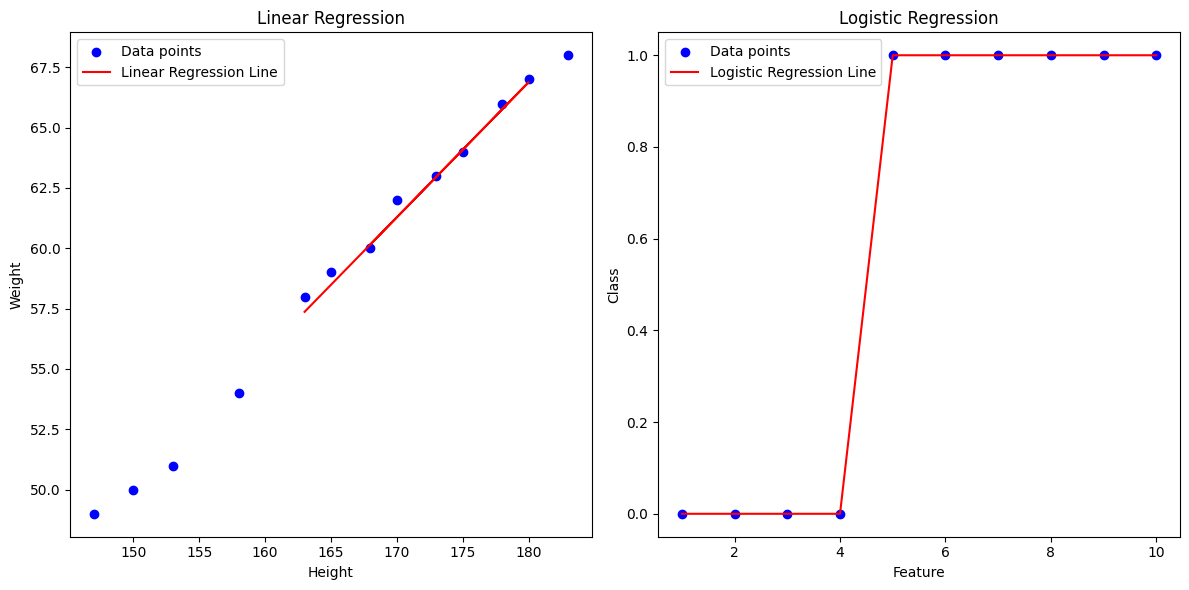

In [ ]:
from sklearn.linear_model import LogisticRegression # type: ignore

import matplotlib.pyplot as plt # type: ignore

# Generate some sample data for logistic regression
X_logistic = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_logistic = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# Train logistic regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_logistic, y_logistic)

# Predict using logistic regression
y_logistic_pred = logistic_model.predict(X_logistic)

# Plot linear regression results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(heihgt, weight, color='blue', label='Data points')
plt.plot(X_test, y_predicted, color='red', label='Linear Regression Line')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Linear Regression')
plt.legend()

# Plot logistic regression results
plt.subplot(1, 2, 2)
plt.scatter(X_logistic, y_logistic, color='blue', label='Data points')
plt.plot(X_logistic, y_logistic_pred, color='red', label='Logistic Regression Line')
plt.xlabel('Feature')
plt.ylabel('Class')
plt.title('Logistic Regression')
plt.legend()

plt.tight_layout()
plt.show()

# Logistic Regresion With steps | customer will defult on thire loan

# Step 1

In [ ]:
%pip install scikit-learn
%pip install numpy
%pip install pandas
%pip install matplotlib

# Load The Data

In [17]:
loan_data = pd.read_csv('loan_data.csv')
loan_data.head()

,age,income,loan_amount,credit_score,default
0,25,50000,20000,700,0
1,45,80000,25000,710,0
2,35,60000,30000,680,1
3,50,120000,10000,720,0
4,23,40000,15000,650,1


# 2 Step | Explore Data

In [18]:
loan_data.describe()

,age,income,loan_amount,credit_score,default
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,37.10000,74200.000000,21200.000000,694.000000,0.300000
std,10.68176,26114.278768,6762.642482,29.135698,0.483046
min,23.00000,40000.000000,10000.000000,650.000000,0.000000
25%,29.50000,56250.000000,16250.000000,680.000000,0.000000
50%,35.50000,68500.000000,21000.000000,695.000000,0.000000
75%,44.25000,87500.000000,25750.000000,707.500000,0.750000
max,55.00000,120000.000000,30000.000000,750.000000,1.000000


# Step 3 | Process Data , will check missing values

In [19]:
loan_data.isnull().sum()

age             0
income          0
loan_amount     0
credit_score    0
default         0
dtype: int64

In [21]:
loan_data = loan_data.dropna()
loan_data.isnull().sum()

age             0
income          0
loan_amount     0
credit_score    0
default         0
dtype: int64

# Seperate X and Y
#### y - defout column
#### X - other columns


# Slipt Data set | Step 4

In [27]:
from sklearn.model_selection import train_test_split  # type: ignore

x = loan_data[['age','income','loan_amount', 'credit_score']]
y = loan_data['default']
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression # type: ignore

# Create a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

# Step 5 Evaluvate Data 

In [32]:
from sklearn.metrics import accuracy_score, recall_score,precision_score, recall_score # type: ignore
y_predicted = model.predict(X_test)

accuracy = accuracy_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


# Task 1

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

customers_data = pd.read_csv('customer_churn_data.csv')

# print(customers_data.head())
# print(customers_data.describe())
# print(customers_data.isnull().sum())

customers_data = customers_data.dropna()
# print(customers_data.isnull().sum())

x = customers_data[['age', 'gender', 'subscription_length', 'total_usage', 'monthly_charges', 'contract_type']]
y = customers_data['churn']

categorical_cols = ['gender', 'contract_type']
numerical_cols = ['age', 'subscription_length', 'total_usage', 'monthly_charges']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

model_pipeline.fit(X_train, y_train)

accuracy = model_pipeline.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


# SVM algorithm

#### this is binary clasification
#### this is under supervice lerning comes
#### we van seperate data set multiple clasifications 
#### we can manipulatie data distances and seperate categories
#### hyporplan , support vectors , margin

# Step 1 | Load Data set

In [56]:
from sklearn import datasets # type: ignore

iris = datasets.load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [73]:
x = iris.data[:100, :2] # first two features and first 100 samples
y = iris.target[:100] # first 100 samples
x

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

# Step 2 | Split Data set

In [64]:
# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Step 3 | import Model

In [67]:
# import model
from sklearn.svm import SVC # type: ignore

classifire = SVC(kernel='linear')
classifire.fit(X_train, y_train)

SVC(kernel='linear')

# Step 4 | Evalvate Clisifire

In [70]:

from sklearn.metrics import accuracy_score # type: ignore

y_pred = classifire.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [79]:
data = [[5.1, 3.7]]
predict = classifire.predict(data)
print(f"Predicted class: {iris.target_names[predict][0]}")

Predicted class: setosa


# Compare the support vector machine 

In [88]:
from sklearn.tree import DecisionTreeClassifier # type: ignore

dicition_tree = DecisionTreeClassifier()
dicition_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [81]:
y_pred_tree = classifire.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


# Visualize the Decition Boundary

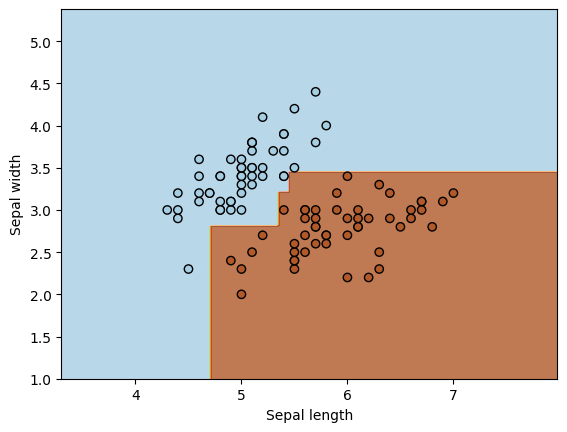

In [89]:
import matplotlib.pyplot as plt # type: ignore

def plot_decision_boundary(classifier, X, y):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.show()

plot_decision_boundary(dicition_tree, x, y)

# StanderScaler

In [94]:
import numpy as np # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore

data = np.array([[25, 50000],[30, 70000],[35, 90000],[40, 120000],[45, 150000],[50, 180000],[55, 200000],[60, 220000],[65, 250000],[70, 300000]])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled


array([[-1.5666989 , -1.45870217],
       [-1.21854359, -1.2005248 ],
       [-0.87038828, -0.94234742],
       [-0.52223297, -0.55508136],
       [-0.17407766, -0.16781529],
       [ 0.17407766,  0.21945077],
       [ 0.52223297,  0.47762815],
       [ 0.87038828,  0.73580552],
       [ 1.21854359,  1.12307159],
       [ 1.5666989 ,  1.76851502]])

# Data persistancy | Persisiting Model

In [118]:
import pandas as pd # type: ignore


music_data = pd.read_csv('music.csv')
music_data.shape


(18, 3)

In [119]:
music_data

,age,gender,genre
0,20,1,HipHop
1,23,1,HipHop
2,25,1,HipHop
3,26,1,Jazz
4,29,1,Jazz
5,30,1,Jazz
6,31,1,Classical
7,33,1,Classical
8,37,1,Classical
9,20,0,Dance


# Gender 
## 1 - MEN
## 0 - Women

In [120]:
x_input_values = music_data.drop(columns=['genre'])
x_input_values

,age,gender
0,20,1
1,23,1
2,25,1
3,26,1
4,29,1
5,30,1
6,31,1
7,33,1
8,37,1
9,20,0


In [121]:
y_output_values = music_data['genre']
y_output_values

0        HipHop
1        HipHop
2        HipHop
3          Jazz
4          Jazz
5          Jazz
6     Classical
7     Classical
8     Classical
9         Dance
10        Dance
11        Dance
12     Acoustic
13     Acoustic
14     Acoustic
15    Classical
16    Classical
17    Classical
Name: genre, dtype: object

In [122]:
import sklearn.tree as DesicionTree # type: ignore

model = DesicionTree.DecisionTreeClassifier()
model.fit(x_input_values, y_output_values)

predictions = model.predict([[22, 1], [28, 0]]) # 22 men and 28 women
predictions



array(['HipHop', 'Acoustic'], dtype=object)

In [129]:
from sklearn.model_selection import train_test_split # type: ignore

x = music_data.drop(columns=['genre'])
y = music_data['genre']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

from sklearn.tree import DecisionTreeClassifier # type: ignore

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions

from sklearn.metrics import accuracy_score # type: ignore

accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


# Persist Modal File

In [134]:
import joblib # type: ignore

joblib.dump(model, 'music-recommender.joblib')

['music-recommender.joblib']

# Saveed Model Useng And Get Prediction

In [133]:
loaded_model = joblib.load('music-recommender.joblib')
predictions = loaded_model.predict([[22, 1], [28, 0]])
predictions

array(['HipHop', 'Acoustic'], dtype=object)